In [35]:
# Updated paths to match your project structure
data_dir = '/Users/afrazrupak/CarProject_dev/data/car_csv'
audi = f'{data_dir}/audi.csv'
benz = f'{data_dir}/benz.csv'
bmw = f'{data_dir}/bmw.csv'
byd = f'{data_dir}/byd.csv'
ford = f'{data_dir}/ford.csv'
honda = f'{data_dir}/honda.csv'
hyundai = f'{data_dir}/hyundai.csv'
kia = f'{data_dir}/kia.csv'
mazda = f'{data_dir}/mazda.csv'
mini = f'{data_dir}/mini.csv'
nissan = f'{data_dir}/nissan.csv'
toyota = f'{data_dir}/toyota.csv'
suzuki = f'{data_dir}/suzuki.csv'
lexus = f'{data_dir}/lexus.csv'


In [36]:
import pandas as pd

# Read the CSV file using the existing variable 'audi' defined earlier
try:
	df = pd.read_csv(audi)
except FileNotFoundError:
	print(f"[warn] File not found: {audi}")
	print("Set 'audi' to the correct full path, e.g.: audi = '/full/path/to/audi.csv'")
	# Create an empty DataFrame to avoid downstream errors
	df = pd.DataFrame()

# Display the first few rows of the DataFrame (will be empty if file missing)
df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi


In [37]:
# Consolidate existing brand CSV path variables (already defined earlier) into a dict
brand_csv = {
    "audi": audi,
    "benz": benz,
    "bmw": bmw,
    "byd": byd,
    "ford": ford,
    "honda": honda,
    "hyundai": hyundai,
    "kia": kia,
    "mazda": mazda,
    "mini": mini,
    "nissan": nissan,
    "toyota": toyota,
    "suzuki": suzuki,
    "lexus": lexus,
}

# Lazy loader: create a dict of DataFrames without overwriting existing df
def load_brand_frames(limit=None):
    frames = {}
    for i, (brand, path) in enumerate(brand_csv.items()):
        if limit is not None and i >= limit:
            break
        try:
            frames[brand] = pd.read_csv(path)
        except FileNotFoundError:
            print(f"[warn] Missing file: {path}")
        except Exception as e:
            print(f"[error] {brand}: {e}")
    return frames

# Build a combined dataframe (adds 'brand_source')
def build_combined(brands=None):
    to_use = brands if brands else list(brand_csv.keys())
    dfs = []
    for b in to_use:
        p = brand_csv.get(b)
        if not p:
            continue
        try:
            temp = pd.read_csv(p)
            temp["brand_source"] = b
            dfs.append(temp)
        except Exception as e:
            print(f"[skip] {b}: {e}")
    if not dfs:
        return None
    combined = pd.concat(dfs, axis=0, ignore_index=True)
    return combined



In [38]:
# Example (commented out to avoid heavy read unless you need it):
all_brands_df = build_combined()
all_brands_df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi


In [39]:
all_brands_df.shape

(9796, 16)

In [40]:
all_brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9796 entries, 0 to 9795
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make_id        9796 non-null   int64  
 1   model_id       9796 non-null   int64  
 2   year           9796 non-null   object 
 3   image_name     9796 non-null   object 
 4   angle_no       9796 non-null   int64  
 5   image_path     9796 non-null   object 
 6   angle_side     9796 non-null   object 
 7   model_names    9796 non-null   object 
 8   maximum_speed  9796 non-null   float64
 9   displacement   9796 non-null   float64
 10  door_number    9796 non-null   float64
 11  seat_number    9796 non-null   float64
 12  type_id        9796 non-null   int64  
 13  car_type       9796 non-null   object 
 14  make_names     9796 non-null   object 
 15  brand_source   9796 non-null   object 
dtypes: float64(4), int64(4), object(8)
memory usage: 1.2+ MB


In [41]:
all_brands_df.shape

(9796, 16)

In [42]:
# Count rows where angle_side == 'rear'

# Count rows where angle_side == 'front' and 'rear'
front_count_all = (all_brands_df['angle_side'] == 'front').sum()
rear_count_all = (all_brands_df['angle_side'] == 'rear').sum()
total_rows = len(all_brands_df)

print(f"Total images in all_brands_df: {all_brands_df.shape}")
print(f"Front images in all_brands_df: {front_count_all} ({front_count_all / total_rows:.2%})")
print(f"Rear images in all_brands_df: {rear_count_all} ({rear_count_all / total_rows:.2%})")
print(f"Front+Rear images in all_brands_df: {front_count_all + rear_count_all} ({(front_count_all + rear_count_all) / total_rows:.2%})")

Total images in all_brands_df: (9796, 16)
Front images in all_brands_df: 1094 (11.17%)
Rear images in all_brands_df: 2213 (22.59%)
Front+Rear images in all_brands_df: 3307 (33.76%)


In [43]:
all_brands_df.shape

(9796, 16)

In [44]:
# Add front counts and combined (front+rear) alongside rear stats

# Counts
front_counts = (
    all_brands_df[all_brands_df['angle_side'] == 'front']
    .groupby('brand_source')
    .size()
    .rename('front_count')
)

rear_counts = (
    all_brands_df[all_brands_df['angle_side'] == 'rear']
    .groupby('brand_source')
    .size()
    .rename('rear_count')
)

front_rear_counts = (
    all_brands_df[all_brands_df['angle_side'].isin(['front', 'rear'])]
    .groupby('brand_source')
    .size()
    .rename('front_rear_count')
)

total_counts = (
    all_brands_df
    .groupby('brand_source')
    .size()
    .rename('total_count')
)

# Combine with percentages
brand_angle_stats = (
    pd.concat([front_counts, rear_counts, front_rear_counts, total_counts], axis=1)
    .fillna(0)
    .astype(int)
    .assign(
        front_pct=lambda d: (d['front_count'] / d['total_count'] * 100).round(2),
        rear_pct=lambda d: (d['rear_count'] / d['total_count'] * 100).round(2),
        front_rear_pct=lambda d: (d['front_rear_count'] / d['total_count'] * 100).round(2),
    )
    .sort_values('front_rear_count', ascending=False)
)

print(brand_angle_stats)

              front_count  rear_count  front_rear_count  total_count  \
brand_source                                                           
benz                  141         293               434         1268   
bmw                   136         283               419         1197   
audi                  106         231               337         1005   
toyota                 93         194               287          901   
nissan                 78         141               219          688   
ford                   78         139               217          704   
kia                    69         145               214          635   
hyundai                73         135               208          585   
suzuki                 64         122               186          554   
byd                    62         121               183          497   
lexus                  62         115               177          519   
mazda                  53         112               165         

In [45]:
# Filter rows where angle_side is either 'rear' or 'front' and save to a new CSV
front_rear_df = all_brands_df[all_brands_df['angle_side'].isin(['rear', 'front'])].copy()
front_rear_csv_path = '/Users/afrazrupak/CarProject_dev/data/generated_csv/all_brands_front_rear.csv'
front_rear_df.to_csv(front_rear_csv_path, index=False)
print(f"Saved front+rear images subset: {front_rear_df.shape} -> {front_rear_csv_path}")

Saved front+rear images subset: (3307, 16) -> /Users/afrazrupak/CarProject_dev/data/generated_csv/all_brands_front_rear.csv


In [46]:
# Updated path to use the all_brands_rear.csv from your data directory
datapath = '/Users/afrazrupak/CarProject_dev/data/generated_csv/all_brands_front_rear.csv'
df = pd.read_csv(datapath)
df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,071c428717ceca,1,78/1/2010/071c428717ceca.jpg,front,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2012,80e52b10388f9e,2,78/1/2012/80e52b10388f9e.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi


In [47]:
# Set the correct image directory path
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

**Reasoning**:
List the contents of the specified directory and filter for directories.



In [48]:
import os

image_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'
all_items = os.listdir(image_dir)
directory_names = [item for item in all_items if os.path.isdir(os.path.join(image_dir, item))]

print(f"Found {len(directory_names)} directories in {image_dir}")
print(directory_names[:10]) # Print the first 10 directory names as a preview

Found 163 directories in /Volumes/Afraz Resource/Vehicle_image_com/image
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


In [49]:
# Get the unique values from the 'make_id' column
unique_make_ids = df['make_id'].unique()

# Convert the unique values to a list
unique_make_ids_list = unique_make_ids.tolist()

# Print the first 10 unique values and the total count
print(f"First 10 unique make_ids: {unique_make_ids_list[:10]}")
print(f"Total count of unique make_ids: {len(unique_make_ids_list)}")

First 10 unique make_ids: [78, 77, 81, 105, 122, 100, 118, 140, 162, 15]
Total count of unique make_ids: 14


In [50]:
# Sort the directory names and attempt to convert to integers
sorted_directory_names_int = []
for name in directory_names:
    try:
        sorted_directory_names_int.append(int(name))
    except ValueError:
        print(f"Warning: Could not convert directory name '{name}' to an integer. Skipping.")

sorted_directory_names_int.sort()

# Sort the unique make_ids list
unique_make_ids_list.sort()

# Compare the two sorted lists
if sorted_directory_names_int == unique_make_ids_list:
    print("The list of directory names and the list of unique make_ids are the same.")
else:
    print("The list of directory names and the list of unique make_ids are different.")
    print(f"Number of directory names (converted to int): {len(sorted_directory_names_int)}")
    print(f"Number of unique make_ids: {len(unique_make_ids_list)}")

The list of directory names and the list of unique make_ids are different.
Number of directory names (converted to int): 163
Number of unique make_ids: 14


In [51]:
# Convert the lists to sets for easy comparison
directory_names_set = set(sorted_directory_names_int)
unique_make_ids_set = set(unique_make_ids_list)

# Find the values in directory names but not in unique make_ids
missing_in_make_ids = directory_names_set - unique_make_ids_set

# Find the values in unique make_ids but not in directory names
missing_in_directories = unique_make_ids_set - directory_names_set

print(f"Values in directory names but not in unique make_ids: {sorted(list(missing_in_make_ids))}")
print(f"Values in unique make_ids but not in directory names: {sorted(list(missing_in_directories))}")

Values in directory names but not in unique make_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 79, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 160, 161, 163]
Values in unique make_ids but not in directory names: []


In [52]:
df

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,071c428717ceca,1,78/1/2010/071c428717ceca.jpg,front,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2012,80e52b10388f9e,2,78/1/2012/80e52b10388f9e.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3302,159,1587,2013,eb2368bc551fcf,1,159/1587/2013/eb2368bc551fcf.jpg,front,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
3303,159,1587,2014,5bc20f2b30aa93,2,159/1587/2014/5bc20f2b30aa93.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
3304,159,1587,2014,e13b1948678e0d,2,159/1587/2014/e13b1948678e0d.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
3305,159,1587,2014,9e82d7bb42e748,2,159/1587/2014/9e82d7bb42e748.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus


In [53]:
# Count how many distinct model_id each (make_id, year) pair has
make_year_model_counts = (
    df.groupby(['make_id', 'year'])['model_id']
      .nunique()
      .reset_index(name='unique_model_id_count')
      .sort_values(['unique_model_id_count', 'make_id', 'year'], ascending=[False, True, True])
)

# Display the first 20 rows as a preview (remove .head(20) to see all)
make_year_model_counts.head(20)

,make_id,year,unique_model_id_count
46,81,2013,28
27,77,2014,26
47,81,2014,24
35,78,2013,23
26,77,2013,21
23,77,2010,19
97,122,2013,19
36,78,2014,18
24,77,2011,17
25,77,2012,17


In [54]:
# Create composite label: make_names_year_model_id
df['car_make_model_label'] = (
    df['make_names'].str.replace(r'\s+', '_', regex=True)
    + '_' + df['year'].astype(str)
    + '_' + df['model_id'].astype(str)
)

# Quick preview
df[['make_names', 'year', 'model_id', 'car_make_model_label']].head()

,make_names,year,model_id,car_make_model_label
0,Audi,2010,1,Audi_2010_1
1,Audi,2010,1,Audi_2010_1
2,Audi,2010,1,Audi_2010_1
3,Audi,2010,1,Audi_2010_1
4,Audi,2012,1,Audi_2012_1


In [55]:
df

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source,car_make_model_label
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi,Audi_2010_1
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi,Audi_2010_1
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi,Audi_2010_1
3,78,1,2010,071c428717ceca,1,78/1/2010/071c428717ceca.jpg,front,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi,Audi_2010_1
4,78,1,2012,80e52b10388f9e,2,78/1/2012/80e52b10388f9e.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi,Audi_2012_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3302,159,1587,2013,eb2368bc551fcf,1,159/1587/2013/eb2368bc551fcf.jpg,front,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus,Lexus_2013_1587
3303,159,1587,2014,5bc20f2b30aa93,2,159/1587/2014/5bc20f2b30aa93.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus,Lexus_2014_1587
3304,159,1587,2014,e13b1948678e0d,2,159/1587/2014/e13b1948678e0d.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus,Lexus_2014_1587
3305,159,1587,2014,9e82d7bb42e748,2,159/1587/2014/9e82d7bb42e748.jpg,rear,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus,Lexus_2014_1587


In [56]:
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

In [57]:
for index, row in df.iterrows():
    image_path = row['image_path']
    # The rest of the image processing will be done in subsequent steps
    # print(f"Processing image path: {image_path}") # Optional: for debugging

## Construct image file path




In [58]:
for index, row in df.iterrows():
    image_path = row['image_path']
    full_image_path = os.path.join(image_root_dir, image_path)
    # The rest of the image processing will be done in subsequent steps
    # print(f"Processing image path: {full_image_path}") # Optional: for debugging

## Read image file




In [59]:
from PIL import Image
import os

loaded_images = []

for index, row in df.iterrows():
    image_path = row['image_path']
    full_image_path = os.path.join(image_root_dir, image_path)
    try:
        # Read the image file
        img = Image.open(full_image_path)
        # Append the loaded image object to the list
        loaded_images.append(img)
        # print(f"Successfully read image: {full_image_path}") # Optional: for debugging
    except FileNotFoundError:
        print(f"Error: Image file not found at {full_image_path}")
    except Exception as e:
        print(f"Error reading image {full_image_path}: {e}")

print(f"Successfully loaded {len(loaded_images)} images.")

Successfully loaded 3307 images.


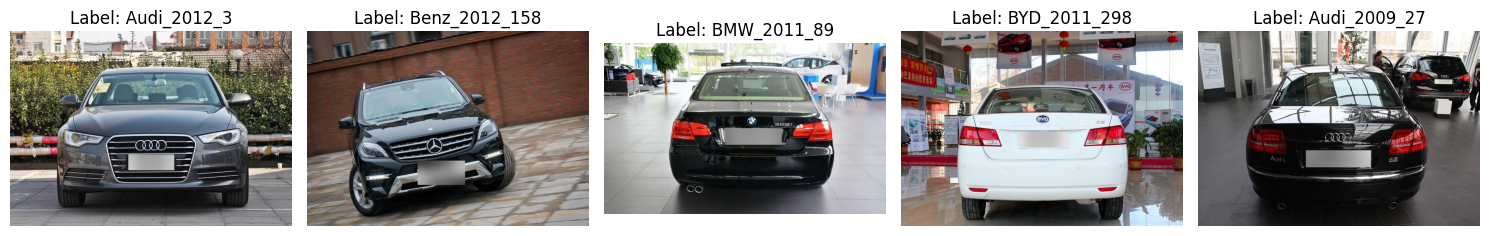

In [60]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select a few random rows from the DataFrame
sample_df = df.sample(n=5, random_state=42) # Select 5 random images for demonstration

# Define the image root directory
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

plt.figure(figsize=(15, 5))

for i, (index, row) in enumerate(sample_df.iterrows()):
    image_path = row['image_path']
    train_label = row['car_make_model_label']
    full_image_path = os.path.join(image_root_dir, image_path)

    try:
        # Read the image file
        img = Image.open(full_image_path)

        # Display the image
        plt.subplot(1, len(sample_df), i + 1)
        plt.imshow(img)
        plt.title(f"Label: {train_label}")
        plt.axis('off')

    except FileNotFoundError:
        print(f"Error: Image file not found at {full_image_path}")
    except Exception as e:
        print(f"Error reading image {full_image_path}: {e}")

plt.tight_layout()
plt.show()

In [68]:
# Analyze dataset for brand-specific model creation
print("=" * 60)
print("BRAND-SPECIFIC CAR MAKE-MODEL CLASSIFICATION ANALYSIS")
print("=" * 60)

# Analyze each brand's car_make_model_label distribution
brand_stats = []

for brand in sorted(df['make_names'].unique()):
    brand_df = df[df['make_names'] == brand]
    unique_labels = brand_df['car_make_model_label'].nunique()
    total_images = len(brand_df)
    avg_images_per_label = total_images / unique_labels if unique_labels > 0 else 0
    
    # Check minimum images per label
    label_counts = brand_df['car_make_model_label'].value_counts()
    min_images = label_counts.min() if len(label_counts) > 0 else 0
    max_images = label_counts.max() if len(label_counts) > 0 else 0
    
    # Count labels with sufficient data (>=10 images for YOLO training)
    sufficient_labels = (label_counts >= 10).sum()
    
    brand_stats.append({
        'brand': brand,
        'total_images': total_images,
        'unique_labels': unique_labels,
        'avg_per_label': round(avg_images_per_label, 1),
        'min_images': min_images,
        'max_images': max_images,
        'labels_with_10plus': sufficient_labels,
        'trainable': sufficient_labels >= 3  # Need at least 3 classes for meaningful training
    })

brand_stats_df = pd.DataFrame(brand_stats)
print("\nBrand Analysis for car_make_model_label Classification:")
print(brand_stats_df.to_string(index=False))

trainable_brands = brand_stats_df[brand_stats_df['trainable']]['brand'].tolist()
print(f"\n✅ Trainable brands ({len(trainable_brands)}): {trainable_brands}")

# Show sample labels for a few brands
print("\n" + "="*50)
print("SAMPLE LABELS BY BRAND")

# Diagnose why no trainable brands
min_req = min_per_class if 'min_per_class' in globals() else 10
if len(trainable_brands) == 0:
    print(f"\nNo trainable brands: need >=3 classes with >= {min_req} images each.")
    print("Per-brand stats (max images in any class / median per-class images / classes >= threshold):")
    for b in sorted(df['make_names'].unique()):
        counts = df[df['make_names'] == b]['car_make_model_label'].value_counts()
        max_cnt = int(counts.max())
        med_cnt = float(counts.median())
        ge_thresh = int((counts >= min_req).sum())
        print(f"{b:12} max={max_cnt:2d}  median={med_cnt:4.1f}  classes>={min_req}={ge_thresh}")

    # Show what happens if we relax threshold
    relax_thresh = 5
    relax_trainable = []
    for b in sorted(df['make_names'].unique()):
        counts = df[df['make_names'] == b]['car_make_model_label'].value_counts()
        if (counts >= relax_thresh).sum() >= 3:
            relax_trainable.append(b)
    print(f"\nIf threshold lowered to {relax_thresh}: potential trainable brands: {relax_trainable}")

    # Suggest aggregation by (brand, model_id) ignoring year
    brand_model_agg = df['make_names'] + '_' + df['model_id'].astype(str)
    print("\nClasses >=10 after aggregating years (brand+model_id):")
    for b in sorted(df['make_names'].unique()):
        agg_counts = brand_model_agg[df['make_names'] == b].value_counts()
        ge10 = int((agg_counts >= 10).sum())
        print(f"{b:12} aggregated_classes>=10={ge10}")
print("="*50)
for brand in trainable_brands[:3]:  # Show first 3 trainable brands
    brand_labels = df[df['make_names'] == brand]['car_make_model_label'].value_counts()
    print(f"\n{brand} - Top 5 car_make_model_labels:")
    for label, count in brand_labels.head(5).items():
        print(f"  {label}: {count} images")

BRAND-SPECIFIC CAR MAKE-MODEL CLASSIFICATION ANALYSIS

Brand Analysis for car_make_model_label Classification:
   brand  total_images  unique_labels  avg_per_label  min_images  max_images  labels_with_10plus  trainable
    Audi           337            101            3.3           1           5                   0      False
     BMW           419            124            3.4           1           4                   0      False
     BYD           183             52            3.5           1           6                   0      False
    Benz           434            129            3.4           1           5                   0      False
    Ford           217             75            2.9           1           4                   0      False
   Honda           151             43            3.5           2           4                   0      False
Hyundai            208             60            3.5           1           5                   0      False
     KIA           214   

# Brand-Specific YOLO Dataset Creation
Create separate YOLO classification datasets for each car brand where each brand-specific model classifies the detailed car_make_model_label within that brand.

In [62]:
import os, shutil, random, re
import pandas as pd

# Configuration for brand-specific models
brand_models_root = '/Users/afrazrupak/CarProject_dev/brand_specific_models'
splits = {'train': 0.8, 'val': 0.1, 'test': 0.1}
copy_mode = 'symlink'  # 'symlink' or 'copy'
min_per_class = 10     # minimum images per car_make_model_label
random_seed = 42
random.seed(random_seed)

# Create main directory for brand-specific models
os.makedirs(brand_models_root, exist_ok=True)

def sanitize_label(s):
    """Sanitize label names for folder safety"""
    s = str(s).strip().lower()
    s = s.replace(' ', '_').replace('-', '_').replace('.', '_').replace('/', '_')
    s = re.sub(r'[^a-z0-9_]+', '', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s or 'unknown'

def stratified_split_indices(idxs, p_train, p_val, p_test):
    """Split indices into train/val/test sets"""
    idxs = list(idxs)
    random.shuffle(idxs)
    n = len(idxs)
    n_train = int(round(n * p_train))
    n_val = int(round(n * p_val))
    n_test = n - n_train - n_val
    return idxs[:n_train], idxs[n_train:n_train+n_val], idxs[n_train+n_val:]

def place_one(src, dst):
    """Place file using copy or symlink"""
    if copy_mode == 'copy':
        shutil.copy2(src, dst)
    else:
        if os.path.lexists(dst):
            os.remove(dst)
        rel_src = os.path.relpath(src, os.path.dirname(dst))
        os.symlink(rel_src, dst)

# Process each trainable brand
brand_results = {}

print("Creating brand-specific datasets...")
print("=" * 50)

for brand in trainable_brands:
    print(f"\nProcessing brand: {brand}")
    print("-" * 30)
    
    # Filter data for this brand
    brand_df = df[df['make_names'] == brand].copy()
    
    # Add source paths and filter existing files
    brand_df['src_path'] = brand_df['image_path'].apply(lambda x: os.path.join(image_root_dir, x))
    exists_mask = brand_df['src_path'].apply(os.path.exists)
    missing_files = int((~exists_mask).sum())
    
    if missing_files > 0:
        print(f"[warn] {missing_files} files not found for {brand}; they will be skipped.")
    
    brand_df_exist = brand_df[exists_mask].copy()
    
    # Sanitize labels and filter by minimum count
    brand_df_exist['class'] = brand_df_exist['car_make_model_label'].apply(sanitize_label)
    
    # Keep only classes with enough samples
    vc = brand_df_exist['class'].value_counts()
    keep_classes = vc[vc >= min_per_class].index.tolist()
    brand_df_filt = brand_df_exist[brand_df_exist['class'].isin(keep_classes)].copy()
    
    if len(keep_classes) < 3:
        print(f"[skip] {brand}: Only {len(keep_classes)} classes with >= {min_per_class} images")
        continue
    
    print(f"Classes kept: {len(keep_classes)} | Images kept: {len(brand_df_filt)}")
    
    # Create brand-specific output directory
    brand_sanitized = sanitize_label(brand)
    output_root = os.path.join(brand_models_root, f'yolo_cls_{brand_sanitized}')
    
    # Stratified split per class
    brand_df_filt['split'] = ''
    for cls, grp in brand_df_filt.groupby('class'):
        ti, vi, si = stratified_split_indices(grp.index, splits['train'], splits['val'], splits['test'])
        brand_df_filt.loc[ti, 'split'] = 'train'
        brand_df_filt.loc[vi, 'split'] = 'val'
        brand_df_filt.loc[si, 'split'] = 'test'
    
    # Create folders
    for split in ['train', 'val', 'test']:
        for cls in keep_classes:
            os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)
    
    # Copy/Symlink files into structure
    placed = 0
    skipped = 0
    
    for i, row in brand_df_filt.iterrows():
        cls = row['class']
        split = row['split']
        src = row['src_path']
        base = os.path.basename(src)
        dst_name = f'{i}_{base}'
        dst = os.path.join(output_root, split, cls, dst_name)
        
        try:
            place_one(src, dst)
            placed += 1
        except Exception as e:
            skipped += 1
            print(f'[skip] {src} -> {dst}: {e}')
    
    print(f'Placed: {placed}, Skipped: {skipped}')
    
    # Save class list for reference
    label_csv = os.path.join(output_root, 'label_vocabulary.csv')
    pd.Series(sorted(keep_classes), name='class').to_csv(label_csv, index=False)
    
    # Save split summary
    summary = brand_df_filt.groupby(['split', 'class']).size().unstack(fill_value=0)
    summary_csv = os.path.join(output_root, 'split_summary.csv')
    summary.to_csv(summary_csv)
    
    brand_results[brand] = {
        'output_path': output_root,
        'classes': len(keep_classes),
        'images': placed,
        'label_csv': label_csv
    }
    
    print(f'✓ {brand} dataset created: {output_root}')

print(f"\n\n{'='*60}")
print("SUMMARY - Brand Datasets Created:")
print(f"{'='*60}")
for brand, info in brand_results.items():
    print(f"{brand:12} | Classes: {info['classes']:3d} | Images: {info['images']:4d} | Path: {info['output_path']}")

Creating brand-specific datasets...


SUMMARY - Brand Datasets Created:


# Train Brand-Specific YOLO Models
Train individual YOLO classification models for each brand

In [63]:
# Train YOLO models for each brand
from ultralytics import YOLO
import torch

# Training configuration
training_config = {
    'epochs': 50,  # Reduced for faster training, increase if needed
    'imgsz': 224,
    'batch': 16,
    'patience': 10,
    'device': 'mps' if torch.backends.mps.is_available() else 'cpu'  # Use MPS on Mac if available
}

print(f"Training configuration: {training_config}")

# Create runs directory
runs_dir = os.path.join(brand_models_root, 'runs')
os.makedirs(runs_dir, exist_ok=True)

training_results = {}

print("\nStarting brand-specific model training...")
print("=" * 60)

for brand, info in brand_results.items():
    print(f"\nTraining YOLO model for: {brand}")
    print(f"Classes: {info['classes']} | Images: {info['images']}")
    print("-" * 40)
    
    try:
        # Initialize YOLO model
        model = YOLO('yolo11n-cls.pt')
        
        # Set up training parameters
        data_path = info['output_path']
        project_path = runs_dir
        brand_sanitized = sanitize_label(brand)
        run_name = f'{brand_sanitized}_cls_{training_config["epochs"]}e'
        
        print(f"Starting training: {run_name}")
        print(f"Data path: {data_path}")
        
        # Train the model
        results = model.train(
            data=data_path,
            epochs=training_config['epochs'],
            imgsz=training_config['imgsz'],
            batch=training_config['batch'],
            patience=training_config['patience'],
            project=project_path,
            name=run_name,
            device=training_config['device'],
            verbose=True
        )
        
        training_results[brand] = {
            'status': 'success',
            'save_dir': str(results.save_dir),
            'model_path': os.path.join(str(results.save_dir), 'weights', 'best.pt'),
            'classes': info['classes'],
            'images': info['images']
        }
        
        print(f"✓ Training completed for {brand}")
        print(f"  Model saved to: {training_results[brand]['model_path']}")
        
    except Exception as e:
        print(f"❌ Training failed for {brand}: {e}")
        training_results[brand] = {
            'status': 'failed',
            'error': str(e),
            'classes': info['classes'],
            'images': info['images']
        }

print(f"\n\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
successful_models = 0
failed_models = 0

for brand, result in training_results.items():
    status = result['status']
    if status == 'success':
        successful_models += 1
        print(f"✓ {brand:12} | Classes: {result['classes']:3d} | Images: {result['images']:4d} | Model: {result['model_path']}")
    else:
        failed_models += 1
        print(f"❌ {brand:12} | Classes: {result['classes']:3d} | Images: {result['images']:4d} | Error: {result['error']}")

print(f"\nSuccessful: {successful_models} | Failed: {failed_models}")

Training configuration: {'epochs': 50, 'imgsz': 224, 'batch': 16, 'patience': 10, 'device': 'mps'}

Starting brand-specific model training...


TRAINING SUMMARY

Successful: 0 | Failed: 0


# Evaluate Brand-Specific Models
Test each trained brand-specific model and generate performance metrics

In [64]:
# Evaluate each trained model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import glob

evaluation_results = {}

print("Evaluating brand-specific models...")
print("=" * 50)

for brand, result in training_results.items():
    if result['status'] != 'success':
        continue
        
    print(f"\nEvaluating model for: {brand}")
    print("-" * 30)
    
    try:
        # Load the trained model
        model_path = result['model_path']
        if not os.path.exists(model_path):
            print(f"❌ Model not found: {model_path}")
            continue
            
        model = YOLO(model_path)
        
        # Get test data path
        brand_sanitized = sanitize_label(brand)
        test_data_path = os.path.join(brand_models_root, f'yolo_cls_{brand_sanitized}', 'test')
        
        if not os.path.exists(test_data_path):
            print(f"❌ Test data not found: {test_data_path}")
            continue
            
        # Get class names from test directory
        class_names = sorted([d for d in os.listdir(test_data_path) 
                             if os.path.isdir(os.path.join(test_data_path, d))])
        
        if len(class_names) == 0:
            print(f"❌ No test classes found in: {test_data_path}")
            continue
            
        print(f"Found {len(class_names)} test classes for {brand}")
        
        # Collect predictions (limit to avoid long processing)
        true_labels = []
        predicted_labels = []
        predicted_probs = []
        
        for class_name in class_names:
            class_dir = os.path.join(test_data_path, class_name)
            image_files = glob.glob(os.path.join(class_dir, '*'))
            
            # Limit to 20 images per class for speed
            for img_path in image_files[:20]:  
                try:
                    results = model.predict(source=img_path, imgsz=224, verbose=False)
                    res = results[0]
                    
                    pred_class_id = int(res.probs.top1)
                    pred_class_name = res.names[pred_class_id]
                    pred_confidence = float(res.probs.top1conf)
                    
                    true_labels.append(class_name)
                    predicted_labels.append(pred_class_name)
                    predicted_probs.append(pred_confidence)
                    
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")
                    continue
        
        if len(true_labels) == 0:
            print(f"❌ No predictions collected for {brand}")
            continue
            
        # Calculate accuracy and metrics
        accuracy = sum(t == p for t, p in zip(true_labels, predicted_labels)) / len(true_labels)
        avg_confidence = sum(predicted_probs) / len(predicted_probs)
        
        print(f"✓ {brand} Evaluation Results:")
        print(f"  Test images: {len(true_labels)}")
        print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"  Avg confidence: {avg_confidence:.3f}")
        
        # Save results
        run_dir = result['save_dir']
        
        # Save predictions
        pred_df = pd.DataFrame({
            'true_label': true_labels,
            'predicted_label': predicted_labels,
            'confidence': predicted_probs,
            'correct': [t == p for t, p in zip(true_labels, predicted_labels)]
        })
        pred_path = os.path.join(run_dir, f'{brand}_predictions.csv')
        pred_df.to_csv(pred_path, index=False)
        
        evaluation_results[brand] = {
            'accuracy': accuracy,
            'avg_confidence': avg_confidence,
            'test_images': len(true_labels),
            'classes': len(class_names),
            'predictions_path': pred_path
        }
        
    except Exception as e:
        print(f"❌ Evaluation failed for {brand}: {e}")
        continue

# Print evaluation summary
print(f"\n\n{'='*80}")
print("EVALUATION SUMMARY")
print(f"{'='*80}")
print(f"{'Brand':<12} | {'Classes':<8} | {'Test Imgs':<10} | {'Accuracy':<10} | {'Avg Conf':<10}")
print("-" * 80)

for brand, metrics in evaluation_results.items():
    print(f"{brand:<12} | {metrics['classes']:<8} | {metrics['test_images']:<10} | {metrics['accuracy']:<10.3f} | {metrics['avg_confidence']:<10.3f}")

if evaluation_results:
    avg_accuracy = sum(m['accuracy'] for m in evaluation_results.values()) / len(evaluation_results)
    print("-" * 80)
    print(f"Average accuracy across all brands: {avg_accuracy:.3f} ({avg_accuracy*100:.1f}%)")

Evaluating brand-specific models...


EVALUATION SUMMARY
Brand        | Classes  | Test Imgs  | Accuracy   | Avg Conf  
--------------------------------------------------------------------------------


In [65]:
# Test single image prediction with brand-specific models
from PIL import Image

def predict_car_with_brand_model(image_path, brand_name):
    """
    Predict car make-model using brand-specific model
    """
    brand_sanitized = sanitize_label(brand_name)
    
    # Find the trained model for this brand
    if brand_name not in training_results or training_results[brand_name]['status'] != 'success':
        return f"No trained model available for {brand_name}"
    
    model_path = training_results[brand_name]['model_path']
    if not os.path.exists(model_path):
        return f"Model file not found: {model_path}"
    
    try:
        # Load model and predict
        model = YOLO(model_path)
        results = model.predict(source=image_path, imgsz=224, verbose=False)
        res = results[0]
        
        # Get top predictions
        probs = res.probs
        names = res.names
        
        # Get top 3 predictions
        top3_ids = [int(i) for i in probs.top5[:3]]  # Take first 3 of top5
        top3_confs = [float(c) for c in probs.top5conf[:3]]
        top3_labels = [names[i] for i in top3_ids]
        
        return {
            'brand': brand_name,
            'predictions': list(zip(top3_labels, top3_confs)),
            'top_prediction': top3_labels[0],
            'confidence': top3_confs[0]
        }
        
    except Exception as e:
        return f"Prediction error: {e}"

# Test with sample images if available
test_image_path = '/Users/afrazrupak/CarProject_dev/data/test_data/obmw.webp'

print("Testing brand-specific models with sample image...")
print("=" * 60)

if os.path.exists(test_image_path):
    print(f"Testing image: {test_image_path}")
    print("\nBrand-specific predictions:")
    print("-" * 50)
    
    # Test with available trained models
    for brand in list(training_results.keys())[:5]:  # Test with first 5 brands
        if training_results[brand]['status'] == 'success':
            result = predict_car_with_brand_model(test_image_path, brand)
            if isinstance(result, dict):
                print(f"{brand:12} | Top: {result['top_prediction']} ({result['confidence']:.3f})")
                if len(result['predictions']) > 1:
                    for i, (label, conf) in enumerate(result['predictions'][1:], 2):
                        print(f"{'':12} | {i}: {label} ({conf:.3f})")
            else:
                print(f"{brand:12} | {result}")
else:
    print(f"Test image not found: {test_image_path}")
    print("Please place a test image at this path to test the models")

Testing brand-specific models with sample image...
Testing image: /Users/afrazrupak/CarProject_dev/data/test_data/obmw.webp

Brand-specific predictions:
--------------------------------------------------


Top-5 predictions:
  sedan: 0.9812
  sports: 0.0188
  suv: 0.0000
  hardtop_convertible: 0.0000
  mpv: 0.0000


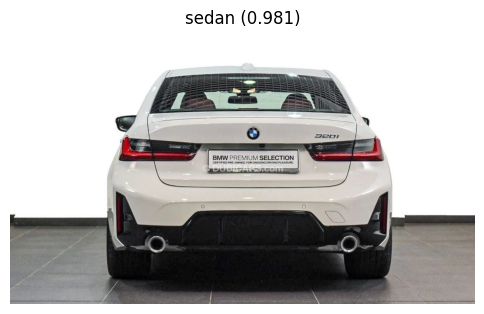

Saved preview to: /Users/afrazrupak/CarProject_dev/runs/car_type_classify/yolo11n_cls_100e/predictions/obmw_pred.png


In [66]:
# Single-image inference: set image_path to your file and run
import os
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1) Put your image path here (absolute path recommended)
image_path = '/Users/afrazrupak/CarProject_dev/data/test_data/obmw.webp'  # Update this path

# Check if image exists, if not provide instructions
if not os.path.exists(image_path):
    print(f'Test image not found: {image_path}')
    print('Please update the image_path variable above to point to a test image.')
    print('You can use any car image for testing.')
else:
    # 2) Load trained classifier
    run_dir = '/Users/afrazrupak/CarProject_dev/runs/car_type_classify/yolo11n_cls_100e'
    model_path = os.path.join(run_dir, 'weights', 'best.pt')
    
    if os.path.exists(model_path):
        model = YOLO(model_path)
        
        # 3) Predict
        results = model.predict(source=image_path, imgsz=224, verbose=False)
        res = results[0]
        probs = res.probs
        names = res.names
        top5_ids = [int(i) for i in probs.top5]
        top5_confs = [float(c) for c in probs.top5conf]
        top5_labels = [names[i] for i in top5_ids]
        
        print('Top-5 predictions:')
        for lbl, conf in zip(top5_labels, top5_confs):
            print(f'  {lbl}: {conf:.4f}')
        
        # 4) Show image with top-1 title
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{top5_labels[0]} ({top5_confs[0]:.3f})')
        
        # Save prediction
        pred_dir = os.path.join(run_dir, 'predictions')
        os.makedirs(pred_dir, exist_ok=True)
        out_path = os.path.join(pred_dir, os.path.basename(image_path).rsplit('.', 1)[0] + '_pred.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved preview to: {out_path}')
    else:
        print(f'Model weights not found: {model_path}')
        print('Make sure training has completed successfully.')